In [1]:
# Import libraries that are required for the creation of the machine learning model
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import os

In [2]:
'''
Russell Larkin
DATA430 6380 Foundations of Machine Learning
Project 1b
Professor Yamil Guevara
'''

'\nRussell Larkin\nDATA430 6380 Foundations of Machine Learning\nProject 1b\nProfessor Yamil Guevara\n'

In [3]:
# Check if the file exists in the current directory
print(f"Current working directory: {os.getcwd()}")

file_name = "Covid Dataset.csv"
if os.path.exists(file_name):
    print(f"'{file_name}' found in the current directory.")
    covid_df = pd.read_csv(file_name)
    print("File loaded successfully.")
    print(covid_df.head())
else:
    print(f"Error: '{file_name}' not found in the current directory.")
    print("Please ensure the file is in the correct directory or provide the correct path.")

Current working directory: /content
'Covid Dataset.csv' found in the current directory.
File loaded successfully.
  Breathing Problem Fever Dry Cough Sore throat Running Nose Asthma  \
0               Yes   Yes       Yes         Yes          Yes     No   
1               Yes   Yes       Yes         Yes           No    Yes   
2               Yes   Yes       Yes         Yes          Yes    Yes   
3               Yes   Yes       Yes          No           No    Yes   
4               Yes   Yes       Yes         Yes          Yes     No   

  Chronic Lung Disease Headache Heart Disease Diabetes  ... Fatigue   \
0                   No       No            No      Yes  ...      Yes   
1                  Yes      Yes            No       No  ...      Yes   
2                  Yes      Yes            No      Yes  ...      Yes   
3                   No       No           Yes      Yes  ...       No   
4                  Yes      Yes           Yes      Yes  ...       No   

  Gastrointestinal  Abroad

In [4]:
#Checking df.info()

covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Breathing Problem                        5434 non-null   object
 1   Fever                                    5434 non-null   object
 2   Dry Cough                                5434 non-null   object
 3   Sore throat                              5434 non-null   object
 4   Running Nose                             5434 non-null   object
 5   Asthma                                   5434 non-null   object
 6   Chronic Lung Disease                     5434 non-null   object
 7   Headache                                 5434 non-null   object
 8   Heart Disease                            5434 non-null   object
 9   Diabetes                                 5434 non-null   object
 10  Hyper Tension                            5434 non-null   obj

In [5]:
covid_df.isnull().sum()

,0
Breathing Problem,0
Fever,0
Dry Cough,0
Sore throat,0
Running Nose,0
Asthma,0
Chronic Lung Disease,0
Headache,0
Heart Disease,0
Diabetes,0


In [6]:
# Checking unique values

covid_df.nunique()

,0
Breathing Problem,2
Fever,2
Dry Cough,2
Sore throat,2
Running Nose,2
Asthma,2
Chronic Lung Disease,2
Headache,2
Heart Disease,2
Diabetes,2


In [7]:
# Remove columns with only one unique value

covid_df = covid_df.drop(columns=['Wearing Masks', 'Sanitization from Market'])

In [8]:
# Transform to int values

covid_df = covid_df.replace({'Yes': 1, 'No': 0})
covid_df.head()

<ipython-input-8-d9fbce85bb6b>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  covid_df = covid_df.replace({'Yes': 1, 'No': 0})


,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,Hyper Tension,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,COVID-19
0,1,1,1,1,1,0,0,0,0,1,1,1,1,0,1,0,1,1,1
1,1,1,1,1,0,1,1,1,0,0,0,1,0,0,0,1,1,0,1
2,1,1,1,1,1,1,1,1,0,1,0,1,1,1,0,0,0,0,1
3,1,1,1,0,0,1,0,0,1,1,0,0,0,1,0,1,1,0,1
4,1,1,1,1,1,0,1,1,1,1,1,0,1,0,1,0,1,0,1


In [9]:
# Check that everything now is of type int

covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Breathing Problem                        5434 non-null   int64
 1   Fever                                    5434 non-null   int64
 2   Dry Cough                                5434 non-null   int64
 3   Sore throat                              5434 non-null   int64
 4   Running Nose                             5434 non-null   int64
 5   Asthma                                   5434 non-null   int64
 6   Chronic Lung Disease                     5434 non-null   int64
 7   Headache                                 5434 non-null   int64
 8   Heart Disease                            5434 non-null   int64
 9   Diabetes                                 5434 non-null   int64
 10  Hyper Tension                            5434 non-null   int64
 11  Fati

In [10]:
# There are four times as many 'Yes' COVID-19 as there are 'No'. 'No' is the minority class.

covid_df['COVID-19'].value_counts()

,count
COVID-19,
1,4383
0,1051


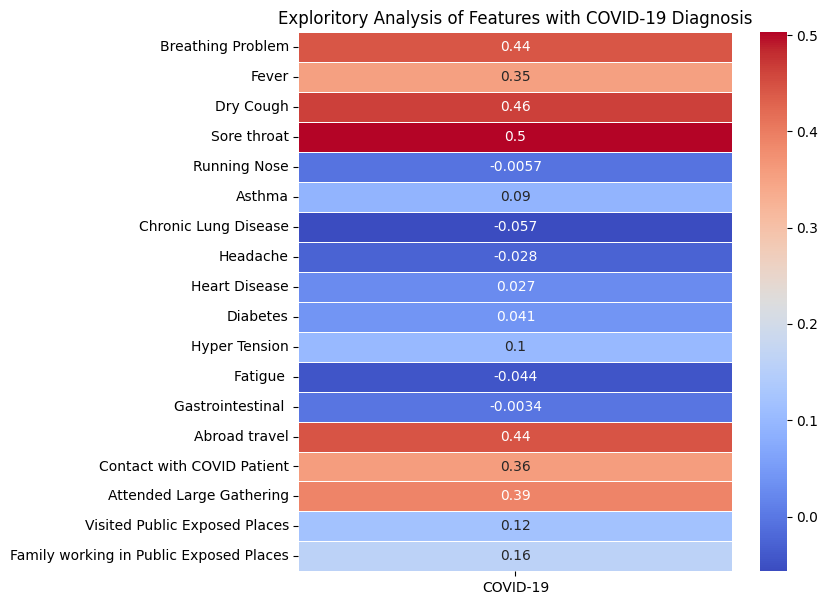

In [11]:
# Exploritory analysis of Target('COVID-19') and Features(variables)

correlation_matrix = covid_df.corr()
target_correlation = correlation_matrix[['COVID-19']].drop('COVID-19')

plt.figure(figsize=(7, 7))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Exploritory Analysis of Features with COVID-19 Diagnosis')
plt.show()

In [12]:
# Created a count of high-impact symptom related "Yes" responses

symptom_cols = [
    'Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat'
]
covid_df['Symptom_Score'] = covid_df[symptom_cols].sum(axis=1)

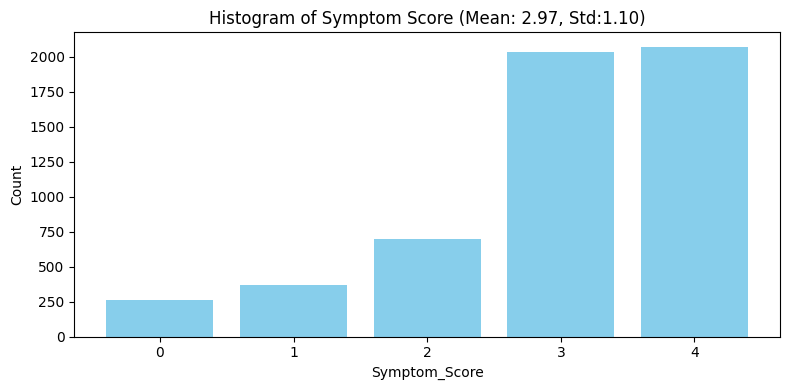

In [13]:
# Distribution of Symptom_Score
SD = covid_df['Symptom_Score'].std()
M = covid_df['Symptom_Score'].mean()

plt.figure(figsize=(8,4))
plt.hist(
    covid_df['Symptom_Score'],
    bins=range(0, covid_df['Symptom_Score'].max()+2),
    align='left',
    rwidth=0.8,
    color='skyblue'
)
plt.xlabel('Symptom_Score')
plt.ylabel('Count')
plt.title(f'Histogram of Symptom Score (Mean: {M:.2f}, Std:{SD:.2f})')
plt.xticks(range(0, covid_df['Symptom_Score'].max()+1))
plt.tight_layout()
plt.show()


In [14]:
# Created a count of high-impact exposure related "Yes" responses

exposure_cols = [
    'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering'
]
covid_df['Exposure_Score'] = covid_df[exposure_cols].sum(axis=1)

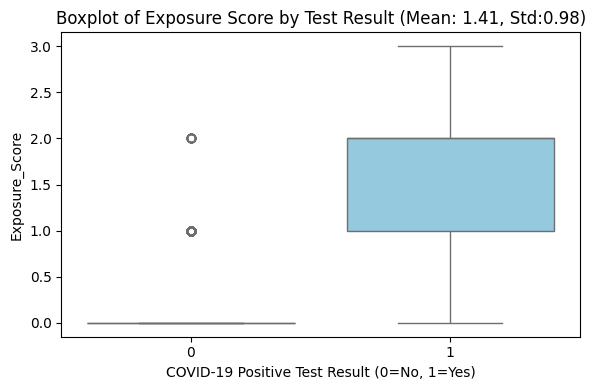

In [15]:
# Exposure_Score by COVID-19 status

SD = covid_df['Exposure_Score'].std()
M = covid_df['Exposure_Score'].mean()

plt.figure(figsize=(6,4))
sns.boxplot(
    x='COVID-19',
    y='Exposure_Score',
    data=covid_df,
    color='skyblue'
)
plt.xlabel('COVID-19 Positive Test Result (0=No, 1=Yes)')
plt.ylabel('Exposure_Score')
plt.title(f'Boxplot of Exposure Score by Test Result (Mean: {M:.2f}, Std:{SD:.2f})')
plt.tight_layout()
plt.show()


In [16]:
# This feature captures people who are symptomatic and highly exposed

covid_df['Symptom_Exposure_Product'] = covid_df['Symptom_Score'] * covid_df['Exposure_Score']

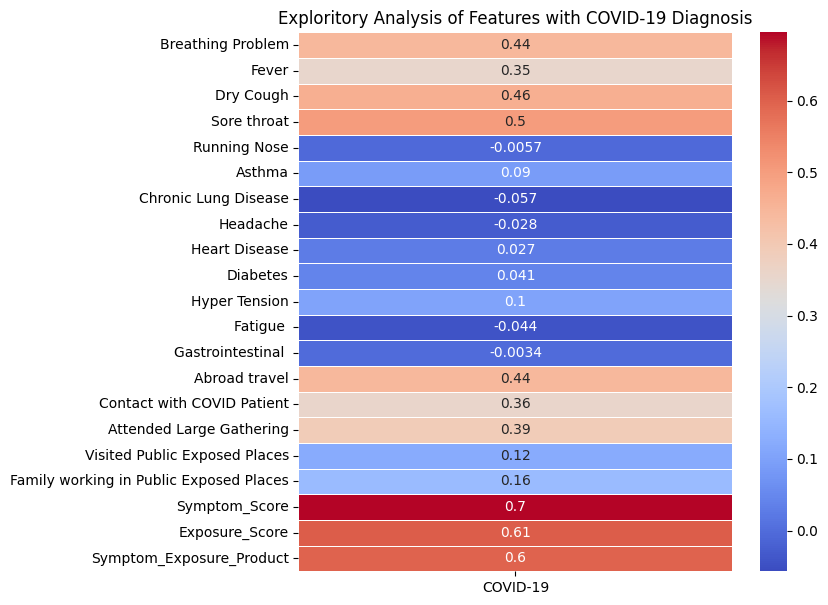

In [17]:
# Exploritory analysis of Target('COVID-19') and all of my Features

correlation_matrix = covid_df.corr()
target_correlation = correlation_matrix[['COVID-19']].drop('COVID-19')

plt.figure(figsize=(7, 7))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Exploritory Analysis of Features with COVID-19 Diagnosis')
plt.show()

In [18]:
X = covid_df.drop(columns=['COVID-19'])
y = covid_df['COVID-19']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4347, 21) (4347,)
Test set: (1087, 21) (1087,)


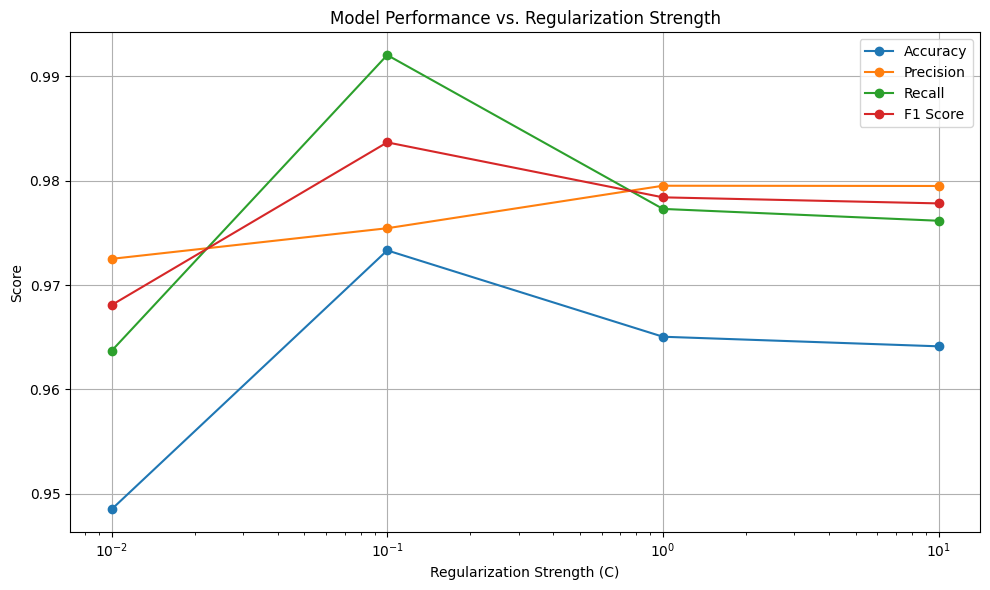

In [20]:
# Created a list of c_values I wanted to test, looped through those values and captured
# the results, then converted those results into a DataFrame that I could plot. Found the
# best C value to be 0.1

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support

# Regularization values to test
c_values = [0.01, 0.1, 1.0, 10.0]
results = []

# Loop through different regularization values
for c in c_values:
    model = LogisticRegression(C=c, solver='liblinear', penalty='l1', max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', pos_label=1)
    accuracy = model.score(X_test, y_test)
    results.append({
        'C': c,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# Convert to DataFrame for plotting
results_df = pd.DataFrame(results)

# Plot the metrics
plt.figure(figsize=(10, 6))
plt.plot(results_df["C"], results_df["Accuracy"], marker='o', label='Accuracy')
plt.plot(results_df["C"], results_df["Precision"], marker='o', label='Precision')
plt.plot(results_df["C"], results_df["Recall"], marker='o', label='Recall')
plt.plot(results_df["C"], results_df["F1 Score"], marker='o', label='F1 Score')
plt.xscale('log')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Score')
plt.title('Model Performance vs. Regularization Strength')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# Settled on using C=0.1 and liblinear. Added a penalty to force the model to drop unhelpful features.

LR = LogisticRegression(C=.1, solver='liblinear', penalty='l1').fit(X_train,y_train)
LR

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')

In [22]:
# View feature importance after model training and evaluation
coeffs = pd.DataFrame({
'Feature': X.columns,
'Coefficient': LR.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("Top influential features:")
print(coeffs.head())

Top influential features:
                                    Feature  Coefficient
13                            Abroad travel     2.323295
15                 Attended Large Gathering     2.199205
18                            Symptom_Score     1.857845
19                           Exposure_Score     1.030127
17  Family working in Public Exposed Places     0.614020


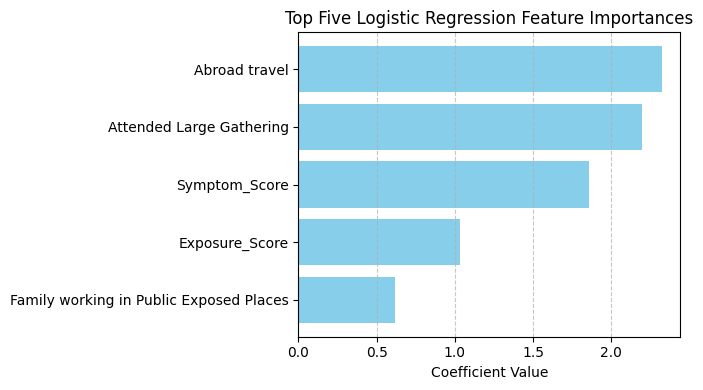

In [23]:
# Plot the most influential features.
top_features = coeffs[coeffs['Coefficient'] > 0].head(5)

plt.figure(figsize=(7, 4))
plt.barh(
    top_features['Feature'],
    top_features['Coefficient'],
    color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top Five Logistic Regression Feature Importances')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
# yhat = LR.predict(X_test)
# yhat

# The standard threshold of 0.5 using LR.predict yeilded 10 false negatives (goal = 0), so I'm customizing the threshold.

# Get predicted probabilities for the positive class (COVID = 1)
probs = LR.predict_proba(X_test)[:, 1]

# Manually iterated by 0.5 down from .5 until I got 0 false negatives on my confusion matrix.
threshold = 0.35

# Apply threshold manually
yhat = (probs >= threshold).astype(int)


In [25]:
# Jaccard Score measures how similar the predicted labels are to the actual labels based on set overlap.

from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat,pos_label=0)

np.float64(0.7864077669902912)

In [26]:
# Log Loss averages how well a model predicted probabilities match the actual outcomes across all samples. Lower = better.

from sklearn.metrics import log_loss
yhat_prob = LR.predict_proba(X_test)
log_loss(y_test, yhat_prob)

0.09152856371042131

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[881   0]
 [ 44 162]]


Confusion matrix, without normalization
[[881   0]
 [ 44 162]]


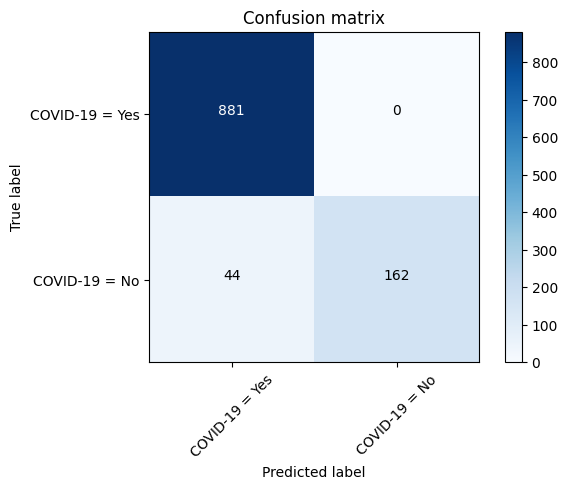

In [28]:
# Compute confusion matrix

cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['COVID-19 = Yes','COVID-19 = No'],normalize= False,  title='Confusion matrix')

In [29]:
print (classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       1.00      0.79      0.88       206
           1       0.95      1.00      0.98       881

    accuracy                           0.96      1087
   macro avg       0.98      0.89      0.93      1087
weighted avg       0.96      0.96      0.96      1087



In [30]:
# Cross Validation
from sklearn.model_selection import cross_val_score

model = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000, penalty='l1')

scores = cross_val_score(model, X, y, cv=5, scoring='recall')  # or 'accuracy', 'f1', etc.
print("Recall scores (5-fold):", scores)
print("Mean Recall:", scores.mean())

Recall scores (5-fold): [0.99 1.   0.96 0.89 0.93]
Mean Recall: 0.9538924727823682
